In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm, Normalize
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin_min
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor, kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)


In [2]:
df = pd.read_csv('total_consumption_data.csv')
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df['datetime'].dtype, np.number):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s', errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

for col in df.columns:
    if col not in ['datetime', 'meter_id']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['meter_id', 'datetime'])

# LOCF imputation per meter (EDA-pipeline consistent)
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
df[num_cols] = df.groupby('meter_id')[num_cols].ffill()
df[num_cols] = df.groupby('meter_id')[num_cols].bfill()

# EDA-consistent structural removal: phase-2/3 channels and redundant totals.
# apower and pfactor are duplicates of apower_ph1 / pfactor_ph1 for single-phase meters.
drop_cols = [
    'aenergy_ph2', 'aenergy_ph3', 'renergy_ph2', 'renergy_ph3',
    'apower_ph2',  'apower_ph3',  'rpower_ph2',  'rpower_ph3',
    'current_ph2', 'current_ph3', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3',
    'apower',      'pfactor',         # aggregate duplicates of ph1 cols
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

# Remove fully-zero numeric columns.
num_cols = [c for c in df.columns if c not in ['datetime', 'meter_id']]
zero_cols = [c for c in num_cols if np.isclose(df[c].fillna(0).abs().sum(), 0)]
if zero_cols:
    df = df.drop(columns=zero_cols)

# Relabel meters A, B, C … (sorted meter_id, consistent with EDA notebook)
meter_ids = sorted(df['meter_id'].dropna().unique().tolist())
meter_map  = {mid: chr(65 + i) for i, mid in enumerate(meter_ids[:26])}
df['meter_label'] = df['meter_id'].map(meter_map)

print('Meter mapping:', meter_map)
print('Shape after cleanup:', df.shape)
df.head(3)


Meter mapping: {'00124B0018D6F607': 'A', '00124B0018D6F74C': 'B', '00124B0018D6F752': 'C', '00124B0018D6F755': 'D', '00124B0018D6FB1E': 'E', '00124B0018D7080C': 'F'}
Shape after cleanup: (144256, 12)


,datetime,meter_id,aenergy,aenergy_ph1,renergy,renergy_ph1,apower_ph1,rpower_ph1,current_ph1,pfactor_ph1,voltage_ph1,meter_label
0,2019-08-27 22:00:05,00124B0018D6F607,4.0,19830.0,0.0,4765.0,242.0,-30.0,1.3,0.9,223.0,A
6,2019-08-27 22:01:05,00124B0018D6F607,4.0,19834.0,0.0,4765.0,287.0,-32.0,1.4,0.9,223.0,A
12,2019-08-27 22:02:05,00124B0018D6F607,11.0,19845.0,0.0,4765.0,1354.0,-34.0,6.1,1.0,221.0,A


In [3]:
df_fe = df.copy()

df_fe['apparent_power_ph1'] = df_fe['voltage_ph1'] * df_fe['current_ph1']
df_fe['pf_angle_ph1']       = np.arccos(np.clip(df_fe['pfactor_ph1'], -1, 1))
df_fe['energy_intensity']   = df_fe['aenergy_ph1'] / (df_fe['apparent_power_ph1'] + 1e-6)
df_fe['Q_P_ratio']          = df_fe['rpower_ph1']  / (df_fe['apower_ph1'].abs() + 1e-6)
df_fe['hour']        = df_fe['datetime'].dt.hour
df_fe['dayofweek']   = df_fe['datetime'].dt.dayofweek
df_fe['is_weekend']  = (df_fe['dayofweek'] >= 5).astype(int)
df_fe['is_peak']     = df_fe['hour'].between(8, 20).astype(int)
df_fe['apower_roll3'] = (
    df_fe.groupby('meter_id')['apower_ph1']
         .rolling(window=3, min_periods=1).mean()
         .reset_index(level=0, drop=True)
)

# 18-feature set matching the EDA report (9 original + 9 engineered)
feature_cols = [
    'aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1',
    'apower_ph1', 'rpower_ph1', 'current_ph1', 'pfactor_ph1', 'voltage_ph1',
    'apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity', 'Q_P_ratio',
    'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3',
]
feature_cols = [c for c in feature_cols if c in df_fe.columns]

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
df_fe[feature_cols] = df_fe[feature_cols].fillna(df_fe[feature_cols].median())

print('Feature set size:', len(feature_cols))
df_fe[feature_cols].describe().T[['mean', 'std', 'min', 'max']]


Feature set size: 18


,mean,std,min,max
aenergy,7.423823,11.815056,0.000000,3.930000e+02
aenergy_ph1,403405.974469,734831.697033,0.000000,2.137274e+06
renergy,0.393627,0.736261,0.000000,2.100000e+01
renergy_ph1,70654.582943,83265.536261,0.000000,2.480900e+05
apower_ph1,389.957894,705.699576,-3858.000000,5.544000e+03
rpower_ph1,8.138005,49.277940,-431.000000,2.940000e+02
current_ph1,2.420847,2.787271,0.100000,2.490000e+01
pfactor_ph1,0.518663,0.618528,-1.000000,1.000000e+00
voltage_ph1,227.076572,8.403890,192.000000,2.400000e+02
apparent_power_ph1,542.962196,617.053293,23.200000,5.555200e+03


Sample: 30000  |  Features: 18  |  PCA-8 explained variance: 0.9543


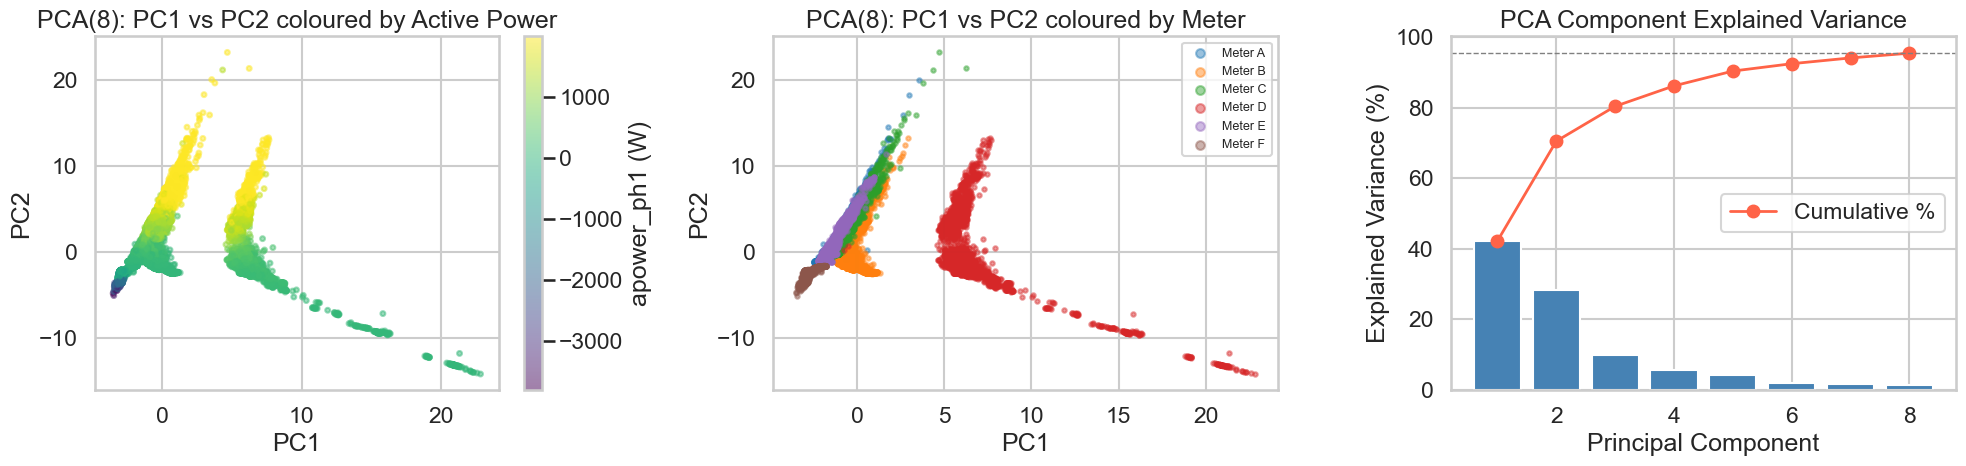

In [4]:
sample_n   = min(30000, len(df_fe))
df_model   = df_fe.sample(n=sample_n, random_state=42).reset_index(drop=True)

X_raw = df_model[feature_cols].copy()
y     = df_model['apower_ph1'].copy()

# Feature-specific scaling (EDA pipeline)
robust_cols   = [c for c in feature_cols if c not in ['hour', 'dayofweek', 'is_weekend', 'is_peak', 'voltage_ph1']]
minmax_cols   = [c for c in ['hour', 'dayofweek', 'is_weekend', 'is_peak'] if c in feature_cols]
standard_cols = [c for c in ['voltage_ph1'] if c in feature_cols]

X_scaled = X_raw.copy()
if robust_cols:   X_scaled[robust_cols]   = RobustScaler().fit_transform(X_scaled[robust_cols])
if minmax_cols:   X_scaled[minmax_cols]   = MinMaxScaler().fit_transform(X_scaled[minmax_cols])
if standard_cols: X_scaled[standard_cols] = StandardScaler().fit_transform(X_scaled[standard_cols])

# 8 PCA components (covers ~96% variance on this dataset)
pca_model   = PCA(n_components=8, random_state=42)
X_pca       = pca_model.fit_transform(X_scaled)
X_2d        = X_pca[:, :2]
explained_8 = pca_model.explained_variance_ratio_.sum()

print(f'Sample: {sample_n}  |  Features: {len(feature_cols)}  |  PCA-8 explained variance: {explained_8:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scatterplot coloured by active power
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y.clip(upper=y.quantile(0.97)),
                     cmap='viridis', s=12, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=axes[0], label='apower_ph1 (W)')
axes[0].set_title('PCA(8): PC1 vs PC2 coloured by Active Power')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Scatterplot coloured by meter
meter_labels_sample = df_model['meter_label']
palette = sns.color_palette('tab10', n_colors=meter_labels_sample.nunique())
for idx, m in enumerate(sorted(meter_labels_sample.unique())):
    mask = meter_labels_sample == m
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=10, alpha=0.45,
                    color=palette[idx], label=f'Meter {m}', rasterized=True)
axes[1].set_title('PCA(8): PC1 vs PC2 coloured by Meter')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=2, fontsize=9)

# Per-component explained variance bar chart
axes[2].bar(range(1, 9), pca_model.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
axes[2].plot(range(1, 9), np.cumsum(pca_model.explained_variance_ratio_) * 100,
             color='tomato', marker='o', lw=2, label='Cumulative %')
axes[2].axhline(explained_8 * 100, color='gray', linestyle='--', lw=1)
axes[2].set_title('PCA Component Explained Variance')
axes[2].set_xlabel('Principal Component'); axes[2].set_ylabel('Explained Variance (%)')
axes[2].legend()

plt.tight_layout()


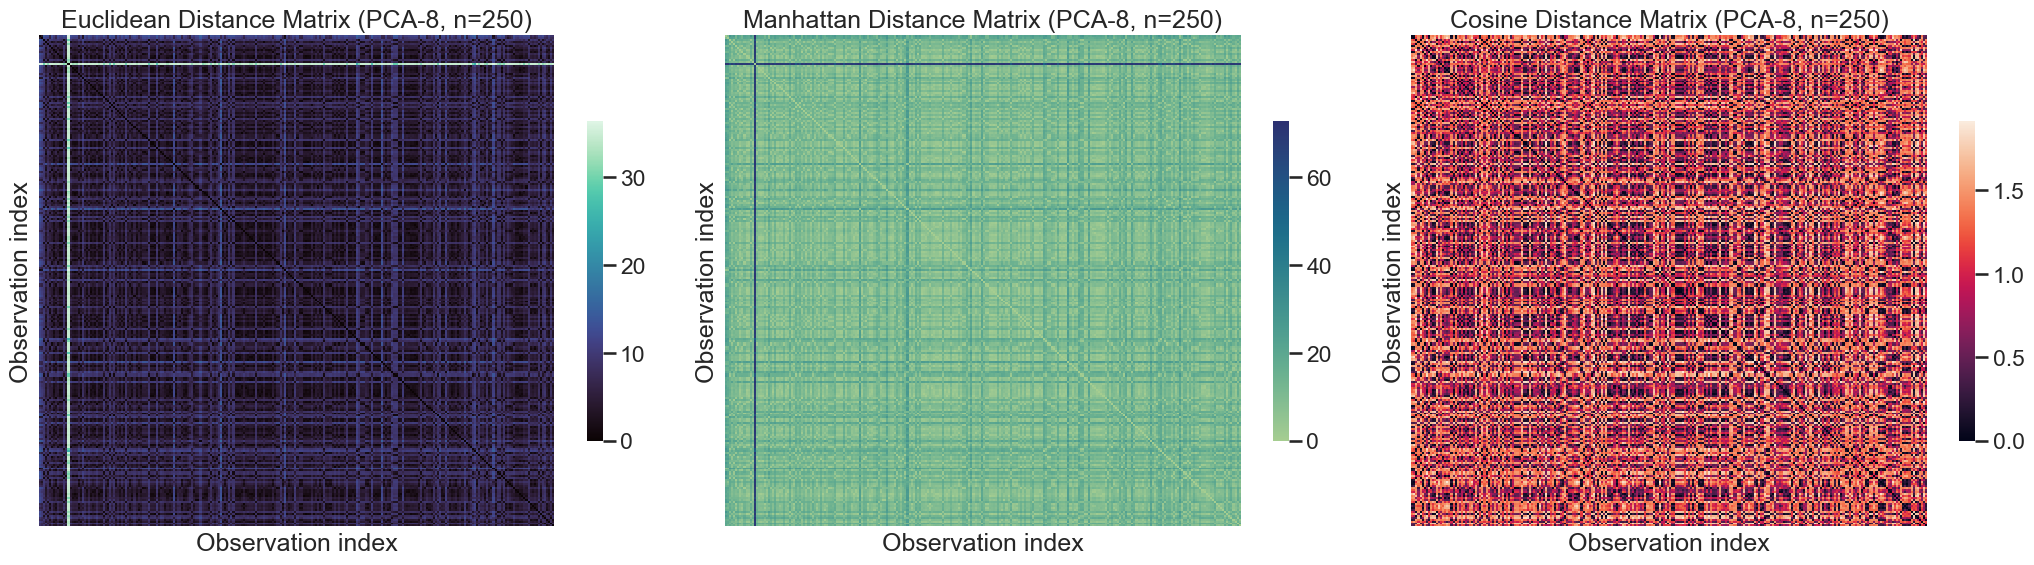

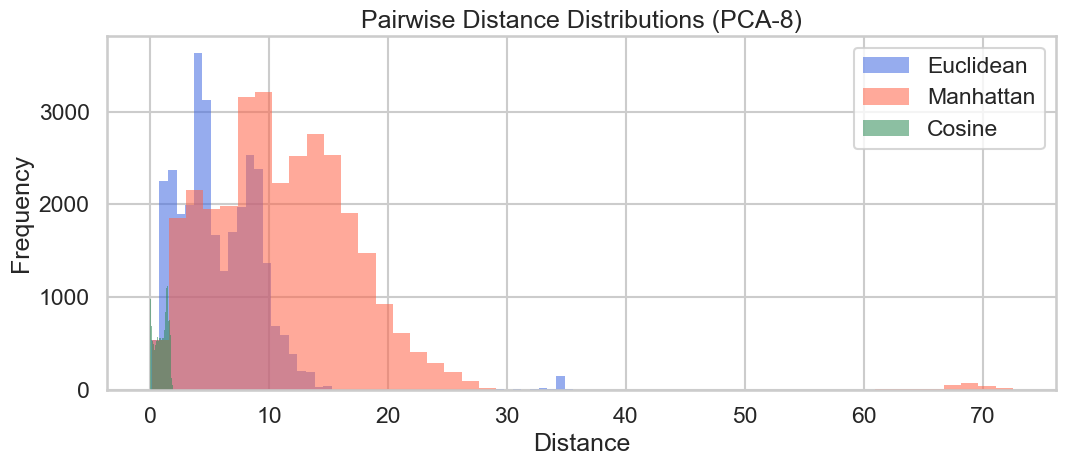

In [5]:
dist_n  = min(250, len(X_pca))
X_dist  = X_pca[:dist_n]

D_eu = pairwise_distances(X_dist, metric='euclidean')
D_ma = pairwise_distances(X_dist, metric='manhattan')
D_co = pairwise_distances(X_dist, metric='cosine')

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, D, title, cmap in zip(
    axes,
    [D_eu, D_ma, D_co],
    ['Euclidean Distance Matrix', 'Manhattan Distance Matrix', 'Cosine Distance Matrix'],
    ['mako', 'crest', 'rocket'],
):
    sns.heatmap(D, cmap=cmap, cbar_kws={'shrink': 0.65}, ax=ax,
                xticklabels=False, yticklabels=False)
    ax.set_title(f'{title} (PCA-8, n={dist_n})')
    ax.set_xlabel('Observation index'); ax.set_ylabel('Observation index')
plt.tight_layout()

# Distribution of pairwise distances
fig, ax = plt.subplots(figsize=(11, 5))
for D, label, color in [(D_eu, 'Euclidean', 'royalblue'),
                         (D_ma, 'Manhattan', 'tomato'),
                         (D_co, 'Cosine',    'seagreen')]:
    vals = D[np.triu_indices_from(D, k=1)]
    ax.hist(vals, bins=50, alpha=0.55, label=label, color=color, edgecolor='none')
ax.set_title('Pairwise Distance Distributions (PCA-8)')
ax.set_xlabel('Distance'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()


Anchor 0  | EU: [0, 21887, 5535, 11935, 6806, 18045, 7763, 6610]
           | Cos: [0, 21887, 21258, 7390, 5346, 10813, 10887, 19945]
           | Man: [0, 21887, 6806, 5535, 11935, 18045, 7390, 6610]
----------------------------------------------------------------------
Anchor 10000  | EU: [10000, 19515, 25997, 21253, 20600, 6442, 22843, 16086]
           | Cos: [10000, 19515, 25997, 21253, 20600, 412, 29481, 16086]
           | Man: [10000, 19515, 25997, 21253, 16086, 20600, 6442, 22843]
----------------------------------------------------------------------
Anchor 20000  | EU: [20000, 17334, 10307, 25527, 22488, 24271, 15892, 13737]
           | Cos: [20000, 17334, 10307, 19489, 20657, 22488, 24271, 15892]
           | Man: [20000, 17334, 10307, 25527, 20657, 19489, 13737, 22488]
----------------------------------------------------------------------


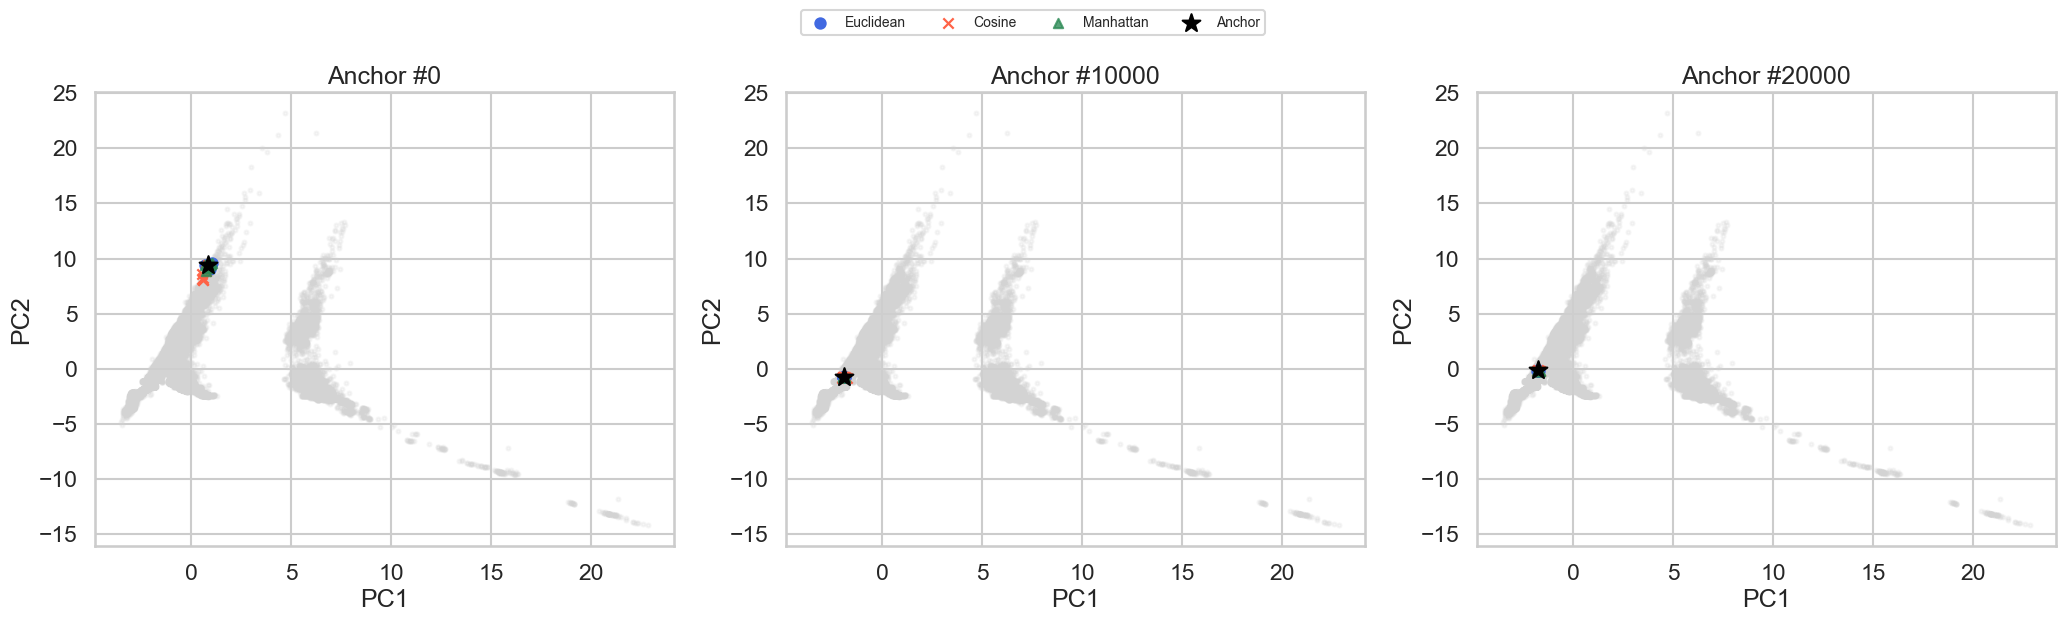

In [6]:
k      = 8
nn_eu  = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_pca)
nn_co  = NearestNeighbors(n_neighbors=k, metric='cosine').fit(X_pca)
nn_ma  = NearestNeighbors(n_neighbors=k, metric='manhattan').fit(X_pca)

anchor_idx           = [0, len(X_pca) // 3, 2 * len(X_pca) // 3]
eu_dist, eu_idx      = nn_eu.kneighbors(X_pca[anchor_idx])
co_dist, co_idx      = nn_co.kneighbors(X_pca[anchor_idx])
ma_dist, ma_idx      = nn_ma.kneighbors(X_pca[anchor_idx])

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for i, a_idx in enumerate(anchor_idx):
    ax = axes[i]
    ax.scatter(X_2d[:, 0], X_2d[:, 1], s=8, alpha=0.20, color='lightgray', rasterized=True)
    ax.scatter(X_2d[eu_idx[i], 0], X_2d[eu_idx[i], 1], s=55, color='royalblue',  zorder=3, label='Euclidean')
    ax.scatter(X_2d[co_idx[i], 0], X_2d[co_idx[i], 1], s=55, color='tomato',     zorder=3, label='Cosine', marker='x', linewidths=1.6)
    ax.scatter(X_2d[ma_idx[i], 0], X_2d[ma_idx[i], 1], s=45, color='seagreen',   zorder=3, label='Manhattan', marker='^', alpha=0.8)
    ax.scatter(X_2d[a_idx, 0],     X_2d[a_idx, 1],     s=180, color='black',     zorder=4, marker='*', label='Anchor')
    ax.set_title(f'Anchor #{a_idx}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.06), fontsize=10)
plt.tight_layout()

for i, a_idx in enumerate(anchor_idx):
    print(f'Anchor {a_idx}  | EU: {eu_idx[i].tolist()}')
    print(f'           | Cos: {co_idx[i].tolist()}')
    print(f'           | Man: {ma_idx[i].tolist()}')
    print('-' * 70)


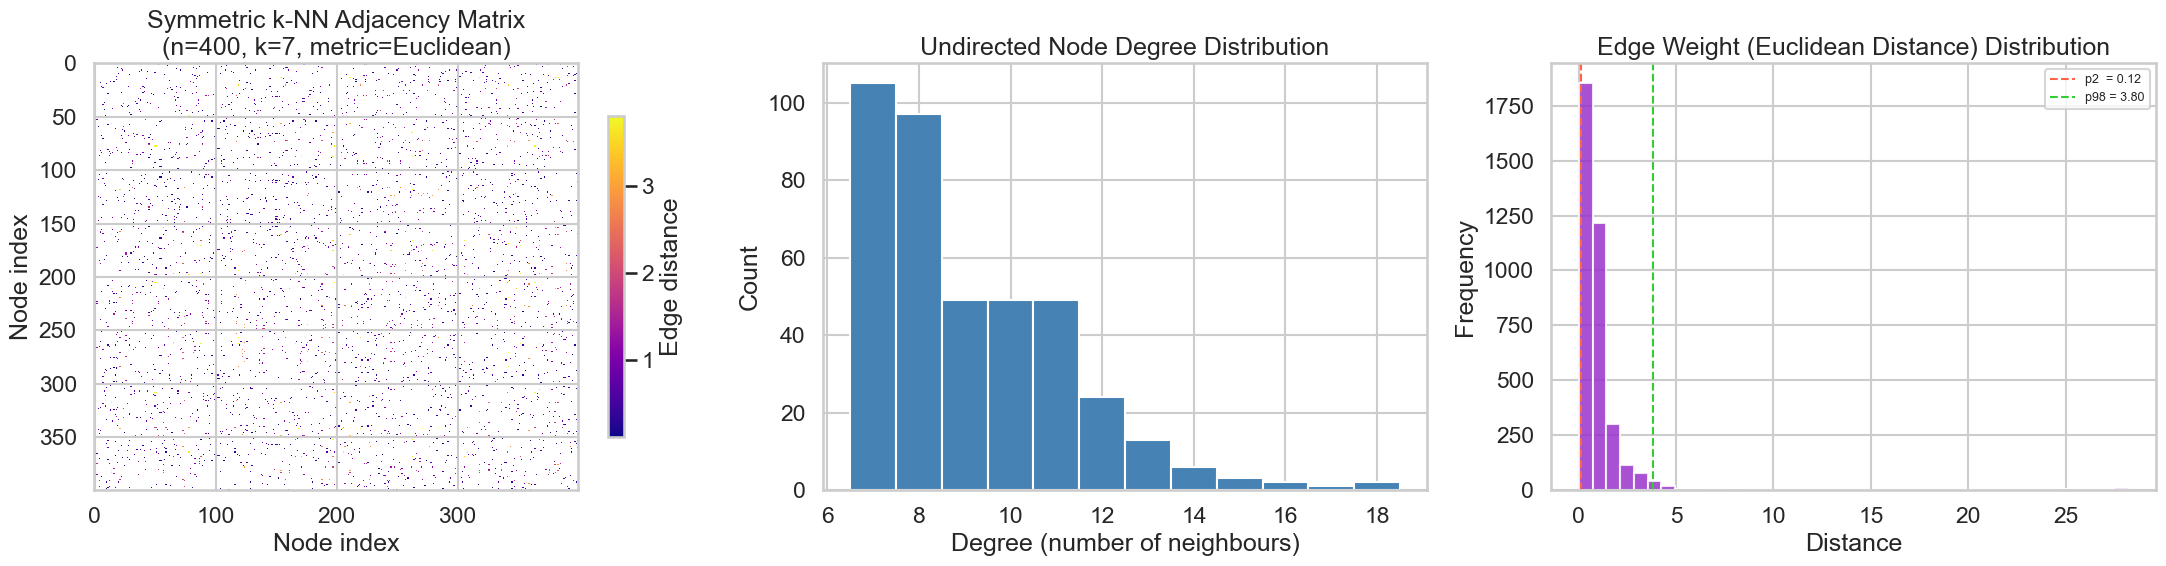

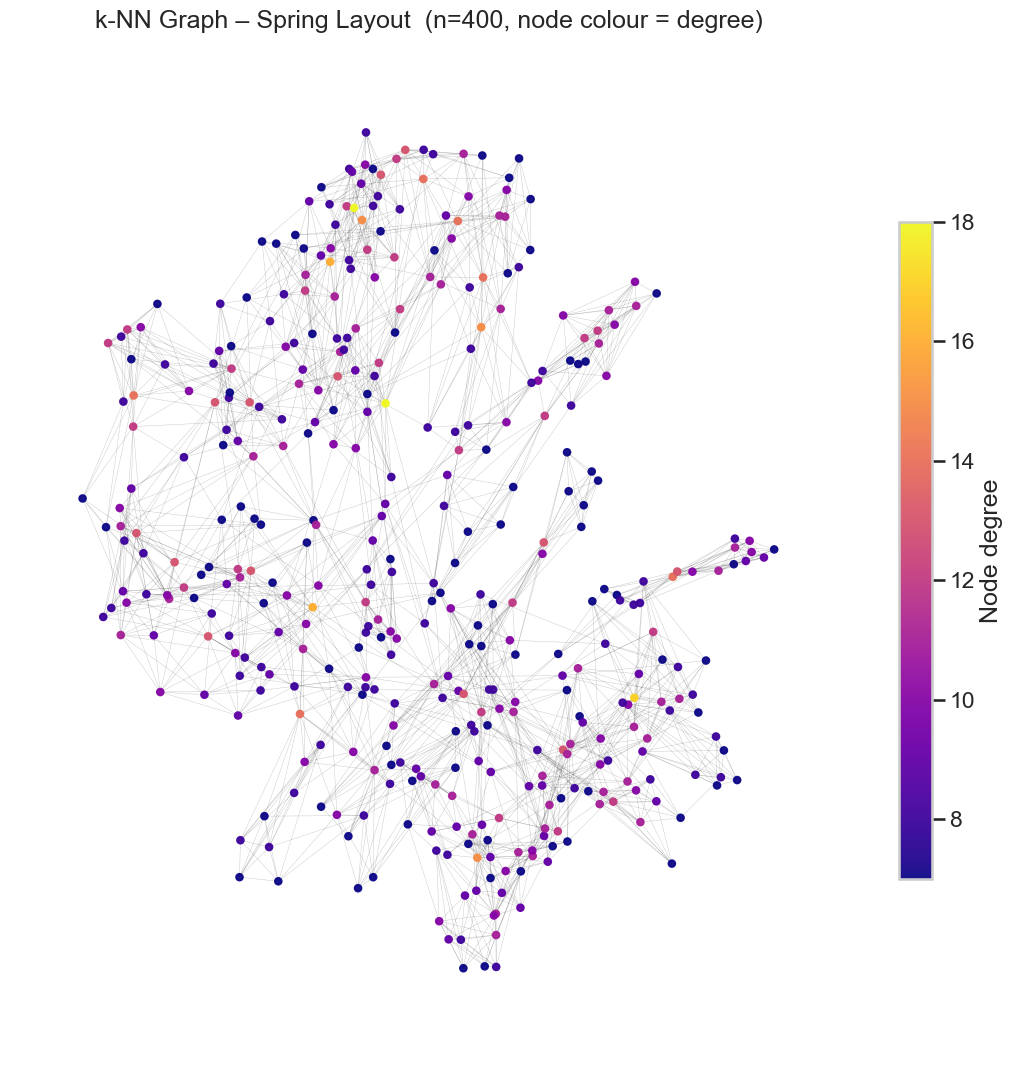

In [7]:
graph_n = min(400, len(X_pca))
A_dir   = kneighbors_graph(X_pca[:graph_n], n_neighbors=7,
                            mode='distance', metric='euclidean', include_self=False)

# Symmetrize
A       = A_dir.maximum(A_dir.T)
A_dense = A.toarray()

# ── Fix: replace zeros with NaN so the colormap only spans actual edges ──
A_plot = A_dense.copy().astype(float)
A_plot[A_plot == 0] = np.nan

# Use percentile-clip for vmin/vmax to ensure full colour range is used
edge_vals = A_dense[A_dense > 0]
vmin = float(np.percentile(edge_vals, 2))
vmax = float(np.percentile(edge_vals, 98))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) Adjacency heatmap with proper colour stretch
im = axes[0].imshow(A_plot, cmap='plasma',
                    vmin=vmin, vmax=vmax,
                    interpolation='nearest', aspect='auto')
plt.colorbar(im, ax=axes[0], label='Edge distance', shrink=0.75)
axes[0].set_title(f'Symmetric k-NN Adjacency Matrix\n(n={graph_n}, k=7, metric=Euclidean)')
axes[0].set_xlabel('Node index'); axes[0].set_ylabel('Node index')

# (b) Degree distribution
degrees = np.asarray((A > 0).sum(axis=1)).ravel()
axes[1].hist(degrees, bins=np.arange(degrees.min(), degrees.max() + 2) - 0.5,
             color='steelblue', edgecolor='white')
axes[1].set_title('Undirected Node Degree Distribution')
axes[1].set_xlabel('Degree (number of neighbours)'); axes[1].set_ylabel('Count')

# (c) Edge-weight distribution
axes[2].hist(edge_vals, bins=40, color='darkorchid', edgecolor='white', alpha=0.85)
axes[2].axvline(vmin, color='tomato',  lw=1.5, linestyle='--', label=f'p2  = {vmin:.2f}')
axes[2].axvline(vmax, color='limegreen', lw=1.5, linestyle='--', label=f'p98 = {vmax:.2f}')
axes[2].set_title('Edge Weight (Euclidean Distance) Distribution')
axes[2].set_xlabel('Distance'); axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=9)

plt.tight_layout()

# NetworkX spring-layout visualisation
try:
    import networkx as nx
    G   = nx.from_scipy_sparse_array(A, edge_attribute='weight')
    pos = nx.spring_layout(G, seed=42, k=0.22)
    node_colors = degrees

    fig2, ax2 = plt.subplots(figsize=(11, 11))
    nc = nx.draw_networkx_nodes(G, pos, node_size=22, node_color=node_colors,
                                 cmap='plasma', alpha=0.95, ax=ax2)
    nx.draw_networkx_edges(G, pos, width=0.30, alpha=0.25, ax=ax2)
    plt.colorbar(nc, ax=ax2, label='Node degree', shrink=0.65)
    ax2.set_title(f'k-NN Graph – Spring Layout  (n={graph_n}, node colour = degree)', pad=12)
    ax2.axis('off')
    plt.tight_layout()
except Exception as e:
    print('NetworkX visualisation skipped:', e)


{'MAE': 12.542436229807084, 'RMSE': 40.17845836600086, 'R2': 0.9965973077800439}


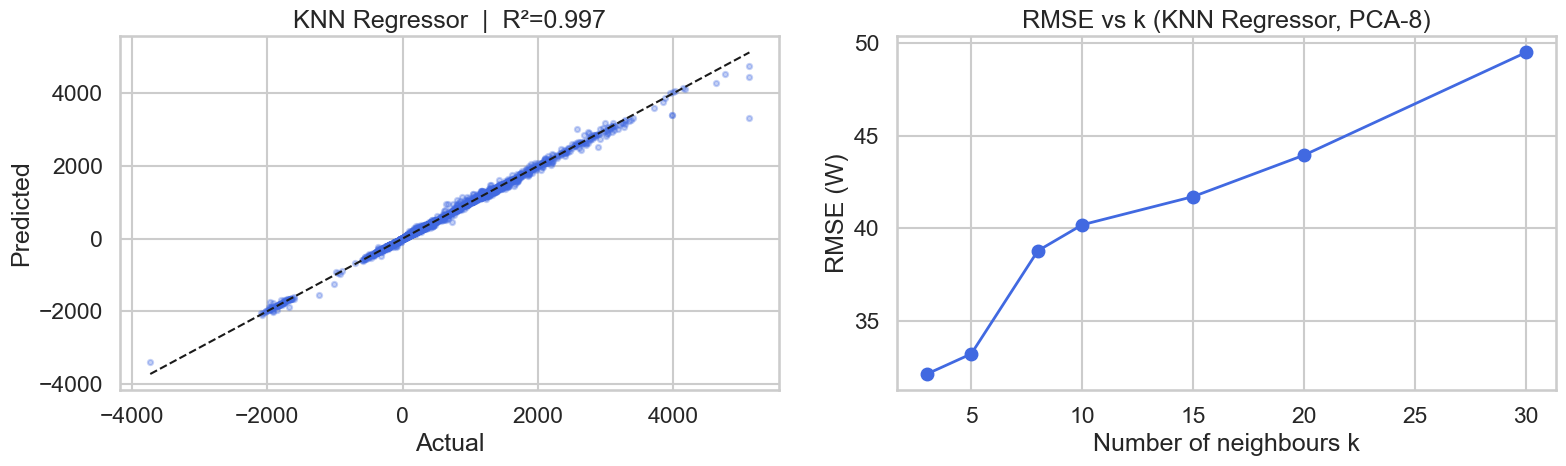

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

knn_reg    = KNeighborsRegressor(n_neighbors=10, metric='minkowski', p=2, weights='distance')
knn_reg.fit(X_train, y_train)
y_pred_knn = knn_reg.predict(X_test)

metrics_knn = {
    'MAE':  mean_absolute_error(y_test, y_pred_knn),
    'RMSE': mean_squared_error(y_test, y_pred_knn, squared=False),
    'R2':   r2_score(y_test, y_pred_knn),
}

# K sweep to show optimal neighbours
ks    = [3, 5, 8, 10, 15, 20, 30]
rmses = []
for ki in ks:
    knn_i = KNeighborsRegressor(n_neighbors=ki, weights='distance').fit(X_train, y_train)
    rmses.append(mean_squared_error(y_test, knn_i.predict(X_test), squared=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(y_test, y_pred_knn, alpha=0.30, s=14, color='royalblue', rasterized=True)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5)
axes[0].set_title(f'KNN Regressor  |  R²={metrics_knn["R2"]:.3f}')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

axes[1].plot(ks, rmses, marker='o', color='royalblue', lw=2)
axes[1].set_title('RMSE vs k (KNN Regressor, PCA-8)')
axes[1].set_xlabel('Number of neighbours k'); axes[1].set_ylabel('RMSE (W)')
plt.tight_layout()

print(metrics_knn)


{'MAE': 16.367828446594388, 'RMSE': 27.031912537480284, 'R2': 0.9984597554622722}


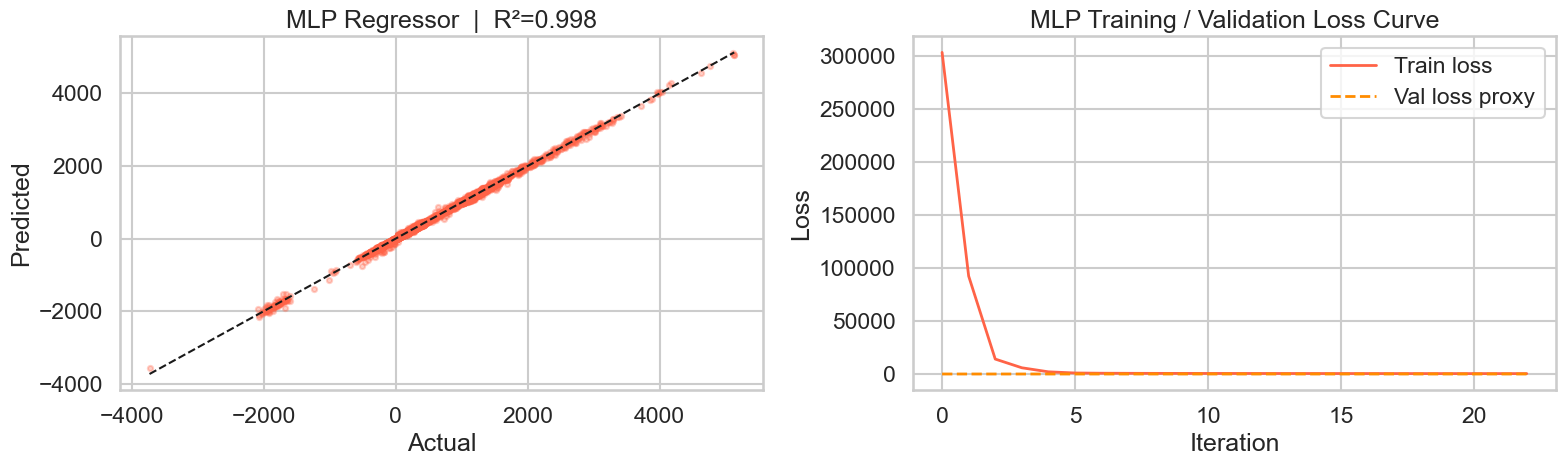

In [9]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=256,
    max_iter=120,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42,
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

metrics_mlp = {
    'MAE':  mean_absolute_error(y_test, y_pred_mlp),
    'RMSE': mean_squared_error(y_test, y_pred_mlp, squared=False),
    'R2':   r2_score(y_test, y_pred_mlp),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(y_test, y_pred_mlp, alpha=0.30, s=14, color='tomato', rasterized=True)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5)
axes[0].set_title(f'MLP Regressor  |  R²={metrics_mlp["R2"]:.3f}')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

axes[1].plot(mlp.loss_curve_, color='tomato', lw=2, label='Train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    val_loss = 1 - np.array(mlp.validation_scores_)
    axes[1].plot(val_loss, color='darkorange', lw=2, linestyle='--', label='Val loss proxy')
axes[1].set_title('MLP Training / Validation Loss Curve')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()

print(metrics_mlp)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3199 - val_loss: 0.1775
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1490 - val_loss: 0.1487
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1298 - val_loss: 0.1441
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1274 - val_loss: 0.1399
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1249 - val_loss: 0.1368
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1225 - val_loss: 0.1350
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1209 - val_loss: 0.1323
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1206 - val_loss: 0.1298
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1195 - val_loss: 0.1304
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1180 - val_loss: 0.1283
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1174 - val_loss: 0.1338
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 

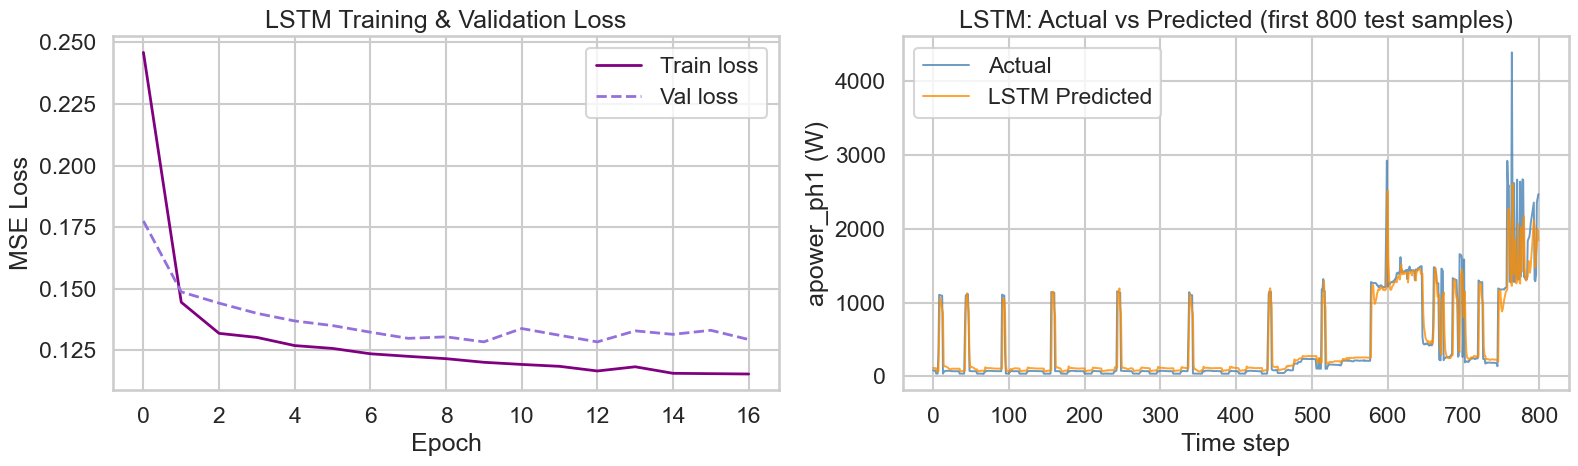

In [10]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(42)

    # Build temporal sequences per meter (sorted by time)
    seq_df       = df_fe.sort_values(['meter_label', 'datetime']).copy()
    seq_features = [c for c in feature_cols if c in seq_df.columns]

    # Scale features & target
    x_scaler      = StandardScaler().fit(seq_df[seq_features])
    y_scaler      = StandardScaler().fit(seq_df[['apower_ph1']])
    X_seq_scaled  = x_scaler.transform(seq_df[seq_features])
    y_seq_scaled  = y_scaler.transform(seq_df[['apower_ph1']]).ravel()

    seq_df_feat   = pd.DataFrame(X_seq_scaled, columns=seq_features, index=seq_df.index)
    seq_df_target = pd.Series(y_seq_scaled, index=seq_df.index)

    lookback = 12
    X_lstm_list, y_lstm_list = [], []
    for _, g in seq_df.groupby('meter_label'):
        Xg = seq_df_feat.loc[g.index].values
        yg = seq_df_target.loc[g.index].values
        if len(Xg) <= lookback:
            continue
        for i in range(len(Xg) - lookback):
            X_lstm_list.append(Xg[i:i + lookback])
            y_lstm_list.append(yg[i + lookback])

    X_lstm = np.array(X_lstm_list[:40000])
    y_lstm = np.array(y_lstm_list[:40000])

    split = int(0.8 * len(X_lstm))
    Xlt, Xlv = X_lstm[:split], X_lstm[split:]
    ylt, ylv = y_lstm[:split], y_lstm[split:]

    lstm_model = Sequential([
        LSTM(64, input_shape=(lookback, X_lstm.shape[2]), return_sequences=True),
        Dropout(0.20),
        LSTM(32),
        Dropout(0.15),
        Dense(16, activation='relu'),
        Dense(1),
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(patience=4, restore_best_weights=True)
    lstm_history = lstm_model.fit(Xlt, ylt, validation_data=(Xlv, ylv),
                                   epochs=20, batch_size=256, callbacks=[es], verbose=1)

    y_pred_lstm_sc = lstm_model.predict(Xlv, verbose=0).ravel()
    y_true_lstm    = y_scaler.inverse_transform(ylv.reshape(-1, 1)).ravel()
    y_pred_lstm    = y_scaler.inverse_transform(y_pred_lstm_sc.reshape(-1, 1)).ravel()

    metrics_lstm = {
        'MAE':  mean_absolute_error(y_true_lstm, y_pred_lstm),
        'RMSE': mean_squared_error(y_true_lstm, y_pred_lstm, squared=False),
        'R2':   r2_score(y_true_lstm, y_pred_lstm),
    }

    print('LSTM sequences:', len(X_lstm), '  |  Metrics:', metrics_lstm)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(lstm_history.history['loss'],     color='purple',     lw=2, label='Train loss')
    axes[0].plot(lstm_history.history['val_loss'], color='mediumpurple', lw=2, linestyle='--', label='Val loss')
    axes[0].set_title('LSTM Training & Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    plot_n = min(800, len(y_true_lstm))
    axes[1].plot(y_true_lstm[:plot_n], color='steelblue',  lw=1.4, label='Actual', alpha=0.8)
    axes[1].plot(y_pred_lstm[:plot_n], color='darkorange', lw=1.4, label='LSTM Predicted', alpha=0.8)
    axes[1].set_title(f'LSTM: Actual vs Predicted (first {plot_n} test samples)')
    axes[1].set_xlabel('Time step'); axes[1].set_ylabel('apower_ph1 (W)')
    axes[1].legend()
    plt.tight_layout()

except Exception as e:
    metrics_lstm    = None
    lstm_history    = None
    y_pred_lstm     = None
    print('LSTM skipped (TensorFlow unavailable or error):', e)


{'MAE': 11.816060603987552, 'RMSE': 42.36540964390676, 'R2': 0.9962168030552221}


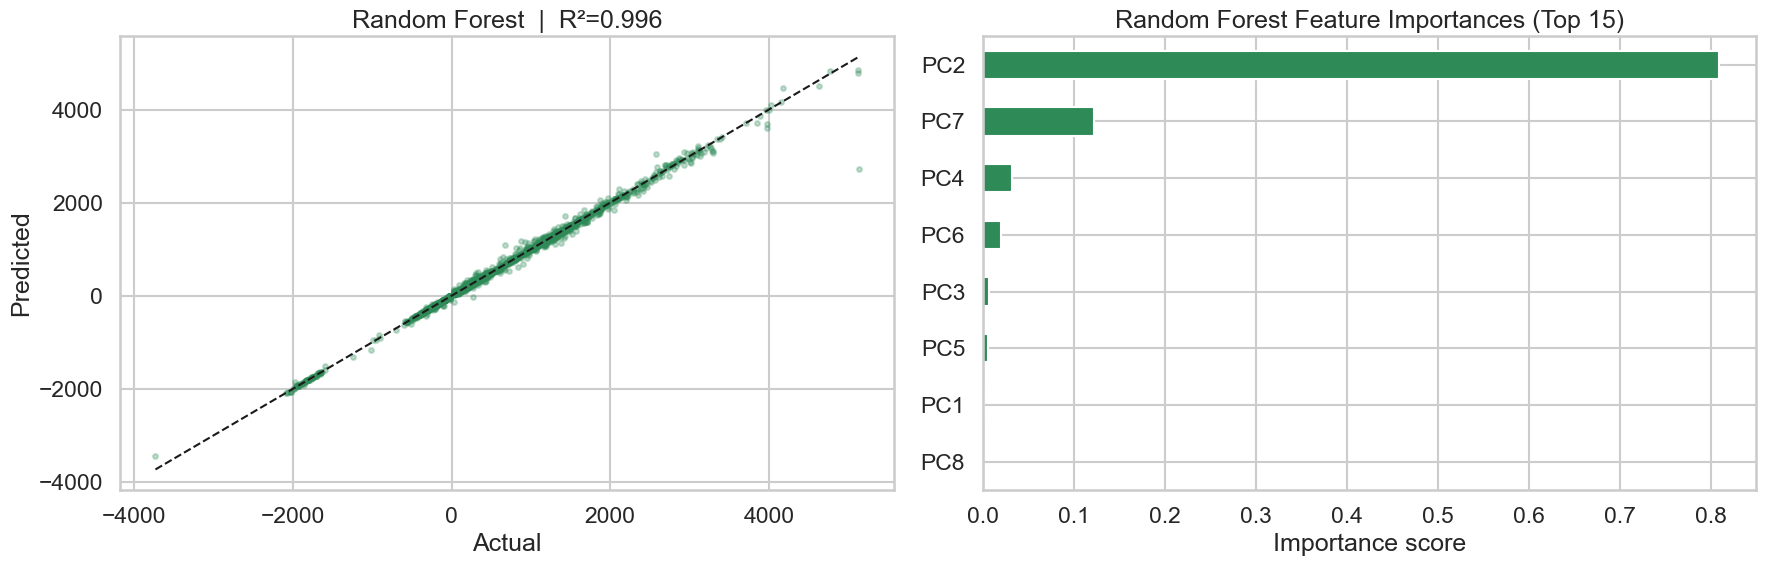

In [12]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=16, min_samples_leaf=2,
    random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

metrics_rf = {
    'MAE':  mean_absolute_error(y_test, y_pred_rf),
    'RMSE': mean_squared_error(y_test, y_pred_rf, squared=False),
    'R2':   r2_score(y_test, y_pred_rf),
}

# Feature importance
importances_rf = pd.Series(rf.feature_importances_, 
                           index=[f'PC{i+1}' for i in range(X_pca.shape[1])]).sort_values(ascending=True).tail(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].scatter(y_test, y_pred_rf, alpha=0.28, s=12, color='seagreen', rasterized=True)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5)
axes[0].set_title(f'Random Forest  |  R²={metrics_rf["R2"]:.3f}')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

importances_rf.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Random Forest Feature Importances (Top 15)')
axes[1].set_xlabel('Importance score')
plt.tight_layout()

print(metrics_rf)


In [ ]:
# Gradient Boosting — ensemble tree method (sklearn HistGradientBoosting for speed)
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=7,
    learning_rate=0.08,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42,
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

metrics_gb = {
    'MAE':  mean_absolute_error(y_test, y_pred_gb),
    'RMSE': mean_squared_error(y_test, y_pred_gb, squared=False),
    'R2':   r2_score(y_test, y_pred_gb),
}

# Permutation importance (works with any estimator)
from sklearn.inspection import permutation_importance
perm = permutation_importance(gb, X_test, y_test, n_repeats=6, random_state=42, n_jobs=-1)
imp_gb = pd.Series(perm.importances_mean,
                   index=[f'PC{i+1}' for i in range(X_pca.shape[1])]).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].scatter(y_test, y_pred_gb, alpha=0.28, s=12, color='darkorchid', rasterized=True)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5)
axes[0].set_title(f'Gradient Boosting  |  R²={metrics_gb["R2"]:.3f}')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

imp_gb.plot(kind='barh', ax=axes[1], color='darkorchid', edgecolor='white')
axes[1].set_title('Gradient Boosting – Permutation Importance (PCA components)')
axes[1].set_xlabel('Mean decrease in R²  (permutation)')
plt.tight_layout()

print(metrics_gb)


,MAE,RMSE,R2
KNN Regressor,11.005607,35.687959,0.997315
MLP Regressor,15.765365,25.044171,0.998678
Random Forest,10.929845,44.317033,0.995860
LSTM,127.558686,274.074288,0.771499


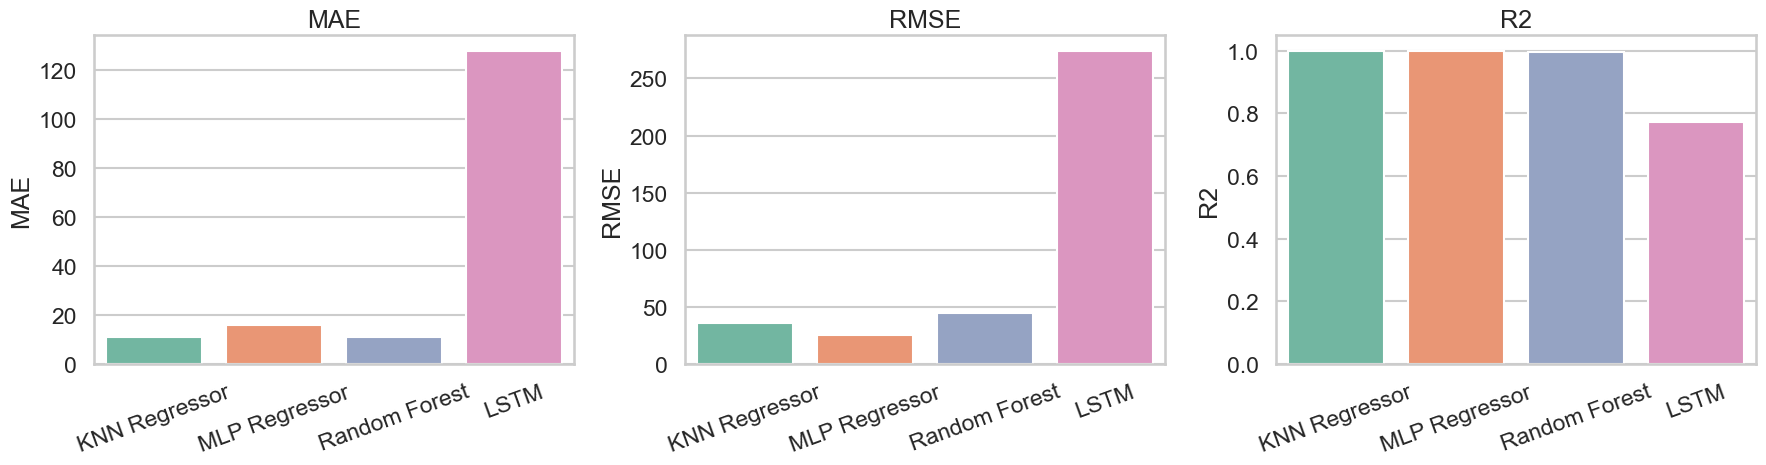

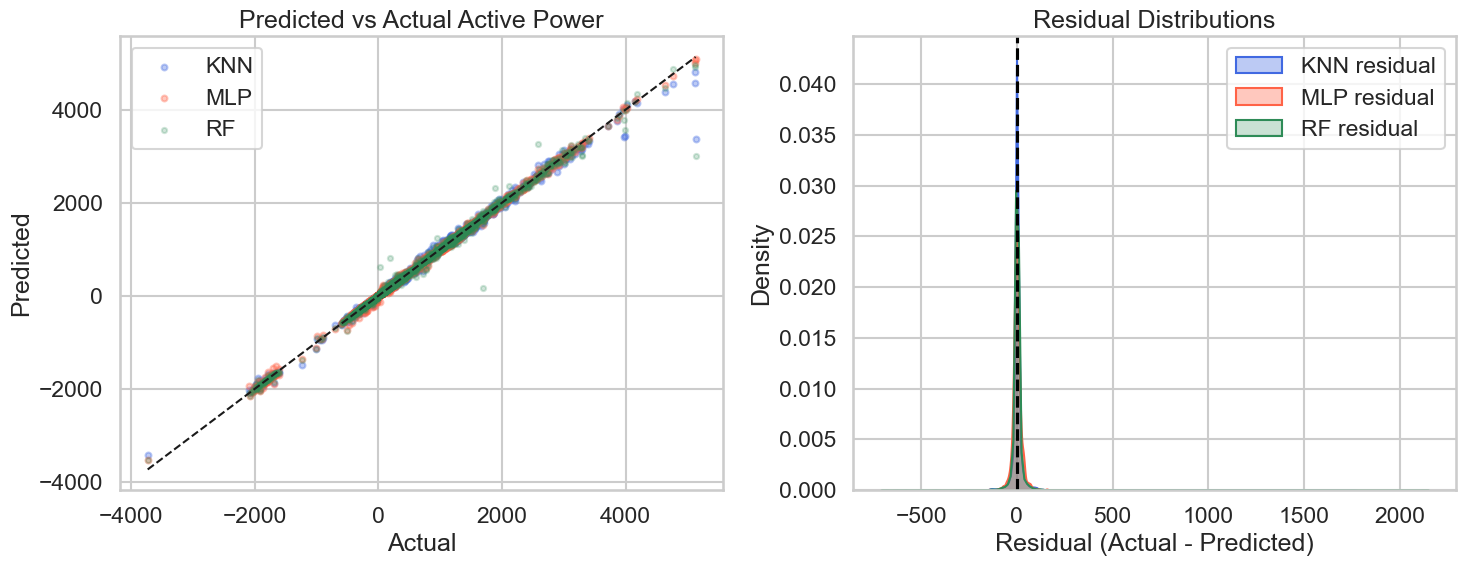

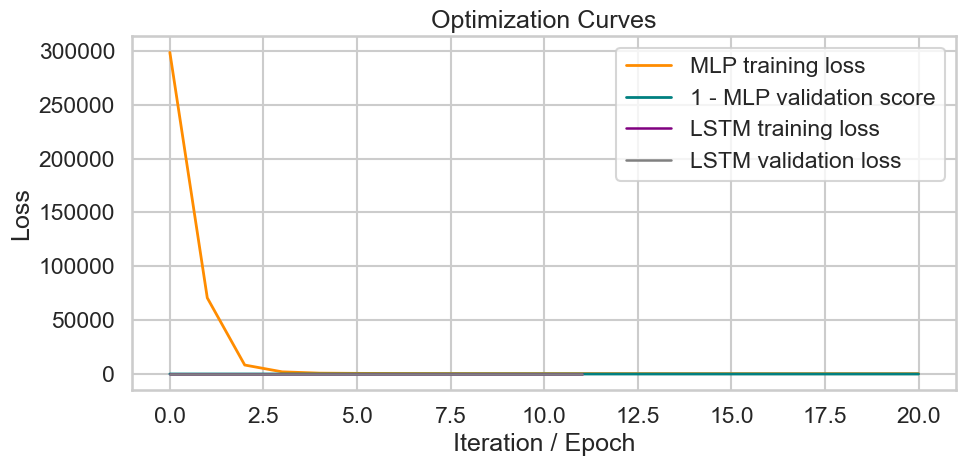

In [ ]:
model_rows = [
    ('KNN Regressor',      metrics_knn),
    ('MLP Regressor',      metrics_mlp),
    ('Random Forest',      metrics_rf),
    ('Gradient Boosting',  metrics_gb),
]
if 'metrics_lstm' in globals() and metrics_lstm is not None:
    model_rows.append(('LSTM', metrics_lstm))

metrics_df = pd.DataFrame([r[1] for r in model_rows], index=[r[0] for r in model_rows])
display(metrics_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
palette = ['royalblue', 'tomato', 'seagreen', 'darkorchid', 'purple'][:len(metrics_df)]
for i, m in enumerate(['MAE', 'RMSE', 'R2']):
    sns.barplot(x=metrics_df.index, y=metrics_df[m], palette=palette, ax=axes[i])
    axes[i].set_title(m)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)
plt.tight_layout()

# Predicted vs actual — all models on one scatter
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred_knn, alpha=0.22, s=10, label='KNN',  color='royalblue', rasterized=True)
ax.scatter(y_test, y_pred_mlp, alpha=0.22, s=10, label='MLP',  color='tomato',    rasterized=True)
ax.scatter(y_test, y_pred_rf,  alpha=0.18, s=10, label='RF',   color='seagreen',  rasterized=True)
ax.scatter(y_test, y_pred_gb,  alpha=0.18, s=10, label='GB',   color='darkorchid',rasterized=True)
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect')
ax.set_title('Predicted vs Actual Active Power — All Models')
ax.set_xlabel('Actual (W)'); ax.set_ylabel('Predicted (W)')
ax.legend(markerscale=2)
plt.tight_layout()

# Residual density comparison
fig, ax = plt.subplots(figsize=(12, 5))
for y_pred, label, color in [
    (y_pred_knn, 'KNN',  'royalblue'),
    (y_pred_mlp, 'MLP',  'tomato'),
    (y_pred_rf,  'RF',   'seagreen'),
    (y_pred_gb,  'GB',   'darkorchid'),
]:
    sns.kdeplot(y_test - y_pred, fill=True, alpha=0.25, label=label, color=color, ax=ax)
ax.axvline(0, color='black', linestyle='--', lw=1.2)
ax.set_title('Residual Distributions (Actual − Predicted)')
ax.set_xlabel('Residual (W)'); ax.legend()
plt.tight_layout()


,meter_label,cosine_distance
0,A,2.220446e-16
1,B,4.525885e-01
2,F,8.889991e-01
3,D,1.226135e+00
4,E,1.264270e+00
5,C,1.596363e+00


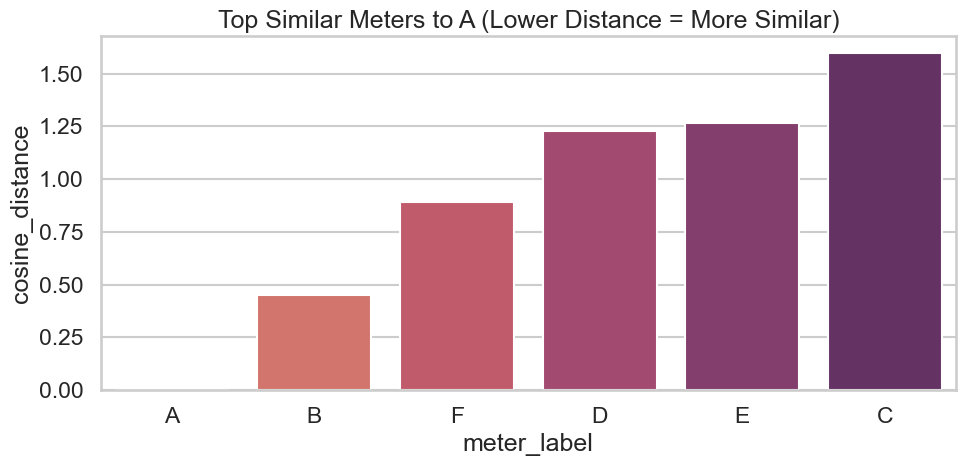

In [ ]:
meter_profile = df_fe.groupby('meter_label')[feature_cols].median().dropna()
meter_profile_scaled = pd.DataFrame(
    RobustScaler().fit_transform(meter_profile),
    index=meter_profile.index, columns=meter_profile.columns,
)

# Pairwise cosine distances between all meters
D_meters = pairwise_distances(meter_profile_scaled.values, metric='cosine')
D_meters_df = pd.DataFrame(D_meters, index=meter_profile.index, columns=meter_profile.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(D_meters_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Cosine distance'})
axes[0].set_title('Pairwise Cosine Distance Between Meters')

query_meter = meter_profile_scaled.index[0]
query_vec   = meter_profile_scaled.loc[[query_meter]].values
cos_all     = pairwise_distances(query_vec, meter_profile_scaled.values, metric='cosine').ravel()
sim_df      = pd.DataFrame({'Cosine Distance': cos_all}, index=meter_profile_scaled.index).sort_values('Cosine Distance')

sns.barplot(data=sim_df.reset_index(), x='meter_label', y='Cosine Distance',
            palette='flare', ax=axes[1])
axes[1].set_title(f'Meter Similarity to Meter {query_meter} (cosine distance)')
axes[1].set_xlabel('Meter'); axes[1].set_ylabel('Cosine Distance')
plt.tight_layout()
display(sim_df)
